# Работа с составными данными



## Строки

Мы уже немного знакомы со строками — это базовый тип данных для работы с текстом. Давайте разберем их подробнее.

Строки очень похожи на другие типы данных в Python (которые мы рассмотрим позже), потому что они обладают важными свойствами:

*   Строки — это *последовательности*.
*   У строк есть встроенные полезные функции — *методы*.
*   Строки *неизменяемы* (их нельзя "подправить" на месте, можно только создать новую строку).

### Последовательности

*Последовательность (sequence)* — это тип данных, который отвечает трем простым правилам:

1. Он состоит из отдельных элементов.
2. У каждого элемента есть свое строгое место (порядок).
3. У последовательности всегда можно узнать длину (сколько в ней элементов).

Как вы думаете, из каких элементов состоит строка?

Ответ простой: строка состоит из более маленьких строк (из отдельных символов).

Давайте посмотрим на примере:

In [ ]:
s = "abc"

В этой строке три элемента. Каждый из них — это тоже маленькая строка из одного символа. Мы можем легко их "склеить" (сложить) обратно:

In [ ]:
s == "a" + "b" + "c"

True

Чтобы узнать, сколько символов в строке, в Python есть стандартная функция `len()` (от английского *length* — длина):

In [ ]:
len(s)

3

А чему будет равна длина "пустой" строки, в которой вообще нет символов?

In [ ]:
len("")

0

Порядок символов в строке определяется с помощью *индексов* (номеров).

> ⚠️ *Очень важное правило:* в программировании отсчет почти всегда начинается с **0**, а не с **1**!

In [ ]:
print(s[0])
print(s[1])
print(s[2])

a
b
c


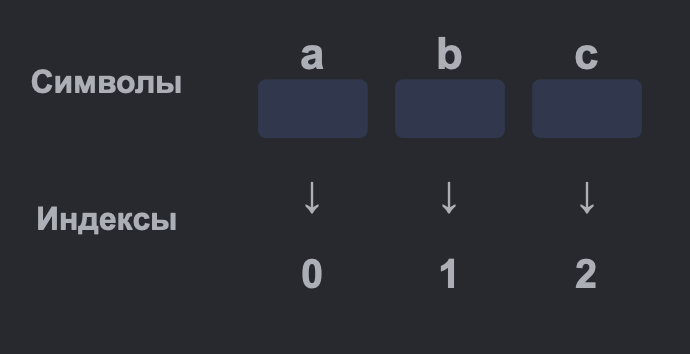

Почему отсчет начинается с нуля?

Так сложилось исторически, ведь компьютеру так проще считать адрес в памяти.

Если представить индекс как *количество шагов (отступ)* от самого начала строки, то первый символ находится в самом начале, то есть наш отступ равен `0`.

Что произойдет, если мы попытаемся обратиться по индексу, которого в строке нет? Например, запросим 4-й символ из трехбуквенной строки:

In [ ]:
s[3]

IndexError: string index out of range

Полезное правило, которое стоит запомнить:

> Если длина строки равна *N*, то индексы в ней идут от *0* до *N - 1*.

In [ ]:
last_index = len(s) - 1
print(s[last_index])

c


Индексы могут быть и отрицательными! В таком случае мы начинаем считать символы *с конца строки* (справа налево). Обратите внимание: отсчет с конца начинается с `-1`.

In [ ]:
print(s[-1])
print(s[-2])
print(s[-3])
print(s[-4])

c
b
a


IndexError: string index out of range

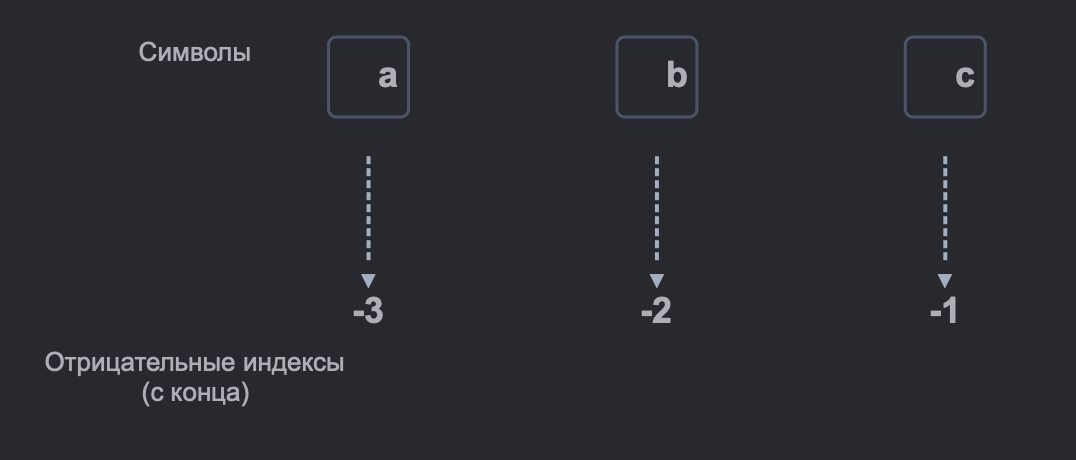

### Слайсы

Работать со строкой по одному символу неудобно.

Решим задачу:

Пользователь вводит дату в формате "ДД.ММ.ГГГГ". Нам нужно отдельно достать день, месяц и год.

In [ ]:
date = input("Введите дату: ")

day = date[0] + date[1]                        # Выделим из даты день
# Еще комментарий
month = date[3] + date[4]                      # месяц
year = date[6] + date[7] + date[8] + date[9]   # и год

print("День:", day)
print("Месяц:", month)
print("Год:", year)

Введите дату: 25.09.2026
День: 25
Месяц: 09
Год: 2026


(Символ `#` и все, что после него - комментарии к коду. Python не распознает их при исполнении, это способ объяснить код людям)

Гораздо удобнее вырезать сразу целую часть строки. Для этого в Python используются *слайсы* (или срезы):

In [ ]:
print(date[0:2])
print(date[3:5])
print(date[6:10])

25
09
2026


Главное правило среза:

> Запись *`X[i:j]`* берет элементы, начиная с индекса *`i`* и заканчивая индексом *`j - 1`* (сам правый конец `j` не включается).

Почему правая граница не включается? Так гораздо проще вычислять длину среза (она всегда равна `j - i`), и делить строку на части без пересечений.

In [ ]:
s = "abcdef"
s[0:3]

> `len(X[i:j]) == j - i`


Нам легко разбить строку на части:

In [ ]:
print(s[0:3])
print(s[3:6])

> `X == X[0, i] + X[i, len(X)]`


В слайсах можно опустить первый индекс - значит, он начнется с **0**:


In [ ]:
date[:2]

'25'

Можно опустить последний индекс - тогда он дойдет до конца последовательности:

In [ ]:
date[6:]

'2026'

А можно ли убрать оба индекса?

In [ ]:
date[:]

'25.09.2026'

Оно же

In [ ]:
date[0:len(date)]

У срезов есть еще один необязательный параметр — *шаг*. Он показывает, с каким интервалом мы берем символы.

Представьте задачу:

У нас есть первые 10 букв английского алфавита, и мы хотим взять только каждую вторую букву.

In [ ]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

Давайте добавим шаг (третье число через двоеточие):

In [ ]:
alphabet[1:10:2]

'bdfhj'

Так мы получим каждый третий символ алфавита:

In [ ]:
alphabet[2::3]

'cfilorux'

А так пропустим каждый второй символ:

In [ ]:
alphabet[::2]

'acegikmoqsuwy'

Раз индексы бывают отрицательными, то и в слайсах мы можем их использовать:

In [ ]:
alphabet[-5:-2]

'vwx'

А если поменять местами?

In [ ]:
alphabet[-2:-5]

''

Чтобы двигаться в обратную сторону (справа налево), нам как раз и пригодится отрицательный шаг:

In [ ]:
alphabet[-2:-5:-1]

'yxw'

Отрицательный шаг `[::-1]` — это самый популярный и простой способ развернуть любую строку задом наперед в Python:

In [ ]:
alphabet[::-1]

'zyxwvutsrqponmlkjihgfedcba'

Например, пропустим каждый второй символ, начиная с конца:

In [ ]:
alphabet[::-2]

'zxvtrpnljhfdb'

### Методы строк

Для начала давайте поймем разницу между *типом данных* (классом) и конкретным *объектом* в Python.

In [ ]:
s = "abc"

`s` — это конкретный *объект*, а `str` (строка) — его *тип данных*.

Можно представить, что тип данных — это чертеж или рецепт, а объект — деталь или готовое блюдо, сделанное по этому рецепту.

В Python есть несколько способов работы с объектами.

Например, привычные нам математические операторы:

In [ ]:
print("abc" + "def")
print("abc" * 3)

abcdef
abcabcabc


Или логические операторы сравнения:

In [ ]:
print("abc" == "abc")
print("ace" == "асе")

True
False


Кстати, чему будет равно это выражение?

In [ ]:
"ab" > "aba"

False

In [ ]:
print(ord("b"))
print(ord("a"))

98
97


Встроенные функции (такие как `str()`, `len()`, `print()`) — универсальные помощники, они умеют работать с самыми разными типами данных:

In [ ]:
str(1)
str(1.5)
str(True)

У отдельных же типов есть *методы* — функции, работающие с конкретным типом данных и связанные с каждым объектом этого типа.

Методы вызываются строго через точку после самого объекта: `объект.метод()`.

Давайте познакомимся с полезными методами строк:

In [ ]:
digits = "1234567890"
print(digits.isnumeric())

True


Метод `.isnumeric()` проверяет, состоит ли строка только из цифр (возвращает `True` или `False`).

In [ ]:
alphabet.isnumeric()

False

А метод `.isalpha()` проверяет, содержит ли строка исключительно буквы:

In [ ]:
print(alphabet.isalpha())
print(digits.isalpha())

emoji = "😊"
print(emoji.isalpha())

True
False
False


Можем проверить, все ли символы прописные или строчные:

In [ ]:
print(alphabet)

print(alphabet.isupper())
print(alphabet.islower())

name = "John"
print(name)
print(name.isupper())
print(name.islower())

abbr = "UNESCO"
print(abbr)
print(abbr.isupper())
print(abbr.islower())

abcdefghijklmnopqrstuvwxyz
False
True
John
False
False
UNESCO
True
False


Методы могут работать отдельно со словами в строке.

Например, все ли слова в строке начинаются с прописной буквы:

In [ ]:
print(name, alphabet, abbr)

print(name.istitle())
print(alphabet.istitle())
print(abbr.istitle())

python_creator = "Guido van Rossum"
print(python_creator.istitle())

John abcdefghijklmnopqrstuvwxyz UNESCO
True
False
False
False


Методы могут иметь дополнительные аргументы.

Существуют методы для поиска в строке:

In [ ]:
print(python_creator)

print(python_creator.find("van"))
print(python_creator.find("John"))

Guido van Rossum
6
-1


Если подстрока найдена - метод вернет индекс, где она обнаружена, если нет - **-1**.

Если нам надо просто проверить, есть ли элемент в последовательности, мы можем использовать оператор `in`:

In [ ]:
print("abc" in alphabet)
print("A" in abbr)

True
False


`.find()` может искать подстроку в каком-то промежутке:

In [ ]:
sentence = "in the house of the rising sun"
print(sentence.find("the"))
print(sentence.find("the", 4))
print(sentence.find("the", 4, 15))

3
16
-1


Первый аргумент - что ищем, второй - начиная с какого индекса, третий - заканчивая каким индексом.

Есть более строгий метод для поиска элементов в последовательности - `.index()`:

In [ ]:
print(sentence.index("the"))
print(sentence.index("the", 4))
print(sentence.index("the", 4, 15))

3
16


ValueError: substring not found

В отличие от `.find()` при ненахождении элемента мы получим ошибку.

У обоих методов есть "братья-близнецы", которые начинают поиск справа - `.rfind()` и `.rindex()`:

In [ ]:
print(sentence.rfind("the"))
print(sentence.rindex("the"))

16
16


Для посчета количества элементов в последовательности есть метод `.count()`:

In [ ]:
print(sentence.count("the"))
print(sentence.count("the", 4))
print(sentence.count("the", 4, 15))

2
1
0


Для проверки, есть ли подстрока в начале или конце строки, существуют методы `.startswith()` и `.endswith()`:

In [ ]:
print(sentence.startswith("in"))
print(sentence.endswith("sun"))

True
True


Как бы мы могли проверить это, не используя методы?

In [ ]:
sentence = "in the house of the rising sun"

print(sentence[:2] == "in")
print(sentence[-3:] == "sun")

True
True


### Неизменяемость

*Неизменяемость (immutability)* — это важное свойство. Оно означает, что мы не можем «отредактировать» уже созданную строку. Любая операция над строкой (сложение, замена букв) не меняет старую строку, а создает *совершенно новый* текстовый объект в памяти.

Такие типы данных как `str`, `int`, `float`, `bool` — неизменяемые.

Давайте проверим это с помощью функции `id()`, которая показывает уникальный адрес объекта в памяти компьютера:

In [ ]:
s = "abc"

print(id(s))

s = s + "def"
print(s)
print(id(s))

132211011668176
abcdef
132210362589872


В Python есть удобная сокращенная запись для изменения переменных.

Вместо длинной записи `X = X + Y` мы можем писать компактнее: `X += Y`.
Это работает со всеми арифметическими знаками (`+=`, `-=`, `*=`, `/=`, `**=`):

In [ ]:
s = "abc"
s += "def"
s

'abcdef'

In [ ]:
i = 100
i *= 5
i

500

Тут тоже можем проверить - мы получаем новый объект!

In [ ]:
i = 2
print(id(i))
i **= 10
print(i)
print(id(i))

10446440
1024
132210007651472


У строк есть ряд методов, при помощи которых можно получить новое значение:

In [ ]:
name = "   ABC   "
print(name.strip())
print(name)
name = name.strip()
print(name)

ABC
   ABC   
ABC


По умолчанию `.strip()` удаляет с обоих краев строки пробелы и символы типа `\n`, но мы можем указать и другие:

In [ ]:
s = "----abc----"
print(s.strip("-"))

url = "www.ecxa.mple.com"
print(url.strip("wcom."))

abc
example


Методы `.rstrip()` и `.lstrip()` работают так же, но только справа или слева соответственно:

In [ ]:
s = "abracadabbbbrrrrraaaaa"
print(s.rstrip("abr"))
print(s.lstrip("abr"))

abracad
cadabbbbrrrrraaaaa


Можем перевести все символы в строке в прописные или строчные:

In [ ]:
alphabet = alphabet.upper()
print(alphabet)

alphabet = alphabet.lower()
print(alphabet)

ABCDEFGHIJKLMNOPQRSTUVWXYZ
abcdefghijklmnopqrstuvwxyz


Методы можно связывать в цепочки (*chaining methods*):

In [ ]:
s = "   abc   "
print(s.strip().upper().count("A"))
print(s)

1
   abc   


Какой результат будет у этого выражения?

In [ ]:
s = "abc"
print(s.upper().lower())

abc


In [ ]:
s[1:3].upper()

'BC'

In [ ]:
s = s[0].upper() + s[1:]
print(s)

Abc


Со всеми методами строк можно ознакомиться [в документации](https://docs.python.org/3/builtins/stdtypes.html#text-sequence-type-str$0).

### Форматирование

Часто нам нужно подставить значения переменных в текстовое значение.

В случае простого вывода на экран нам достаточно функции `print()`.

Например, поприветствуем пользователя:

In [ ]:
username = input("Введите свое имя: ")
print("Привет, ", username, "!")

Введите свое имя: Игорь
Привет,  Игорь !


Если же нам нужно сохранить получившийся текст в новую переменную, склеивание плюсами быстро превратится в кашу.

In [ ]:
message = "Привет, " + username + "!"

Это не самый удобный способ записи.


Для красивой и удобной подстановки переменных в текст лучше всего использовать *f-строки* (форматированные строки):

In [ ]:
message = f"Привет, {username}!"
print(message)

Привет, Игорь!


Просто добавьте букву `f` перед кавычками, и внутри фигурных скобок `{}` вы сможете указывать любые переменные или даже вычисления:

In [ ]:

width = int(input("Введите ширину прямоугольника: "))
height = int(input("Введите высоту прямоугольника: "))

print(f"Площадь прямоугольника: {width * height}")

Введите ширину прямоугольника: 10
Введите высоту прямоугольника: 20
Площадь прямоугольника: 200


In [ ]:
print(f"Имя пользователя прописными буквами: {username.upper()}")

Имя пользователя прописными буквами: ИГОРЬ


Во время разработки нам может понадобиться проверка значения переменной, причем с указанием ее названия.

Для этого есть специальный синтаксис:

In [ ]:
print(f"Получили переменные: {width=} и {height=}")

Получили переменные: width=10 и height=20


## Циклы в Python

Обработка элементов последовательностей — обычно повторяющаяся процедура.

Представьте, что нам нужно проверить регистр (строчная или прописная) каждого символа в строке без циклов. Нам пришлось бы копировать код для каждого индекса вручную:

In [ ]:
s = "abc"

symbol = s[0]
if symbol.isupper():
    print(f"{symbol} - прописная буква")
else:
    print(f"{symbol} - строчная буква")

symbol = s[1]
if symbol.isupper():
    print(f"{symbol} - прописная буква")
else:
    print(f"{symbol} - строчная буква")

symbol = s[2]
if symbol.isupper():
    print(f"{symbol} - прописная буква")
else:
    print(f"{symbol} - строчная буква")

a - строчная буква
b - строчная буква
c - строчная буква


А если в строке будет 100 символов? Чтобы избавить нас от рутины и повторения кода, в программировании придумали *циклы*.

### for

Базовым циклом для работы с последовательностями является `for`.

На простом языке его логику можно описать так:

> Для каждого элемента в последовательности: выполни вот это действие



In [ ]:
s = "abc"

for c in s:
    print("Следующий символ в строке:")
    print(c)
print("Цикл закончился")

Следующий символ в строке:
a
Следующий символ в строке:
b
Следующий символ в строке:
c
Цикл закончился


Давайте перепишем последнюю задачу аккуратно и компактно с помощью цикла:

In [ ]:
s = "abc"

for symbol in s:  # Возьмем по очереди каждый символ из s и сохраним в symbol
    if symbol.isupper():
        print(f"{symbol} - прописная буква")
    else:
        print(f"{symbol} - строчная буква")

a - строчная буква
b - строчная буква
c - строчная буква


На каждом витке (*итерации*) цикла:

* из последовательности берется следующий по очереди элемент
* значение присваивается переменной
* обрабатывается в блоке цикла
* очередь переходит к следующему элементу

Когда очередь элементов закончится - завершит работу и цикл.

### Алгоритм

Большинство задач на обработку последовательностей с помощью цикла `for` решаются по схожему шаблону.

Основные шаги алгоритма с циклом:

* *Инициализация (Подготовка):*
   Создаем переменные для хранения промежуточных результатов работы цикла.
   * Если нужно что-то *посчитать* — создаем счетчик с минимальным значением.
   * Если нужно найти *максимум/минимум* — создаем переменную для хранения кандидата c крайним значением или первым подходящим элементом.
   * Если нужно получить *новую* последовательность — создем переменную с  пустой последовательностью.

* *Итерация (Обход последовательности):*
   Запускаем цикл `for element in sequence:` для последовательного перебора всех элементов.

* *Анализ (Проверка условий):*
   На каждом шаге цикла проверяем текущий элемент с помощью условной конструкции `if`, подходит ли он под условие задачи?

* *Тело цикла (Логика внутри цикла)*
   Если условие выполняется, проводим необходимые операции с элементом.

* *Вывод результата:*
   После того как цикл полностью завершился (и мы перебрали все элементы), мы анализируем созданные на этапе инициализации переменные и выводим результат.


   Решим задачи:

   Посчитаем, сколько гласных в предложении:

In [ ]:
sentence = input("Введите предложение: ")
vowels = "аоуыэиеюяёАОУЫЭИЕЮЯЁ"

count = 0

for symbol in sentence:
    print(f"Символ: {symbol}")
    if symbol in vowels:
        count += 1
    print(f"Счетчик: {count}")


print(f"Количество гласных в предложении: {count}")

Обработаем строку и напечатаем самую большую цифру, что нам встретится.

Подсказка: Для проверки того, является ли символ  цифрой, используйте уже знакомый нам метод `.isnumeric()`.

In [ ]:
text = input("Введите строку с цифрами: ")

max_number = -1

for symbol in text:
    if symbol.isnumeric():
        symbol = int(symbol)
        if symbol > max_number:
            max_number = symbol

if max_number >= 0:
    print(f"Максимальная цифра в строке: {max_number}")
else:
    print("Чисел в строке нет")

Введите строку с цифрами: a0b1c2
symbol='a' Чисел в строке нет
symbol='b' Чисел в строке нет
symbol='c' Чисел в строке нет
Максимальная цифра в строке: 2


Отфильтруем строку и создадим новую строку, в которой останутся только буквы (все остальные символы должны быть проигнорированы).

Подсказка: Для проверки того, является ли символ буквой, используйте уже знакомый нам метод `.isalpha()`.

In [ ]:
mixed_text = input("Введите строку с буквами, цифрами и знаками: ")

letters = ""

for symbol in mixed_text:
    if symbol.isalpha():
        letters += symbol


print(letters)

Введите строку с буквами, цифрами и знаками: a0b1c2d3
abcd


Заменим все пробелы в введенной строке на символ нижнего подчеркивания `_`.

Если символ не является пробелом, мы просто переносим его в новую строку без изменений.

In [ ]:
user_string = input("Введите предложение для замены пробелов: ")

sentence = ""

for symbol in user_string:
    if symbol != " ":
        sentence += symbol
    else:
        sentence += "_"

print(sentence)

Введите предложение для замены пробелов: а что это такое
а_что_это_такое


### continue

Иногда во время обхода последовательности нам нужно пропустить текущую итерацию цикла и сразу перейти к следующей, не выполняя оставшийся код внутри тела цикла. Для этого используется инструкция `continue`.

Как только Python встречает команду `continue`:

1. Он завершает выполнение текущего шага (итерации) цикла.

2. Игнорирует все строки кода, которые идут ниже `continue` внутри этого цикла.

3. Переходит к следующему элементу последовательности и начинает новую итерацию.

Давайте посмотрим на примере: мы хотим распечатать все символы строки, кроме восклицательных знаков.

In [ ]:
text = "Привет! Как! Дела!"

for char in text:
    print(f"Символ: {char}")
    if char == "!":
        continue  # Пропускаем восклицательный знак, переходим к следующему символу
    print(f"Не восклицательный знак: {char}")
    print("После символа")

### break

Иногда нам требуется не просто пропустить итерацию, а полностью **прервать выполнение цикла** до того, как он дойдет до конца последовательности. Для этого используется инструкция `break`.

Как только Python встречает команду `break` внутри цикла, выполнение этого цикла мгновенно прекращается, и программа переходит к коду, который идет сразу после цикла.

Представим, что нам нужно вырезать первое слово из строки (все символы до первого пробела). Как только мы встретим пробел, продолжать цикл больше нет смысла:

In [ ]:
text = "Hello World"
first_word = ""

for char in text:
    if char == " ":
        break  # Выходим из цикла полностью
    first_word += char

print("Первое слово:", first_word)

Первое слово: Hello


Допустим, мы проверяем пароль на безопасность. Если в нем есть хотя бы один запрещенный символ (например, знак решетки `#`), мы сразу можем сказать, что пароль некорректен, и прекратить проверку:

In [ ]:
password = "secret#pass#abcde"
has_forbidden = False

for char in password:
    print(char)
    if char == "#":
        has_forbidden = True
        break  # Нашли запрещенный символ, дальше искать нет смысла

if has_forbidden:
    print("Пароль содержит запрещенные символы.")
else:
    print("Пароль корректен.")

Решим задачу.

Пользователь бросает кубик и получает очки, от 1 до 6. При достижении 50 очков игра заканчивается. Напишем программу, которая посчитает, на каком броске игра закончится:

In [ ]:
attempts = input("Введите результаты бросков кубика:")

score = 0
step = 1


for attempt in attempts:
    attempt = int(attempt)
    score += attempt
    if score >= 50:
        print(f"Игра закончилась на шаге {step}")
        break
    step += 1


Введите результаты бросков кубика:666666666
Игра закончилась на шаге 9


### Вложенные циклы

Иногда для решения задач одного цикла оказывается недостаточно. В таких случаях внутри одного цикла мы можем запустить другой цикл. Такой синтаксис называется *вложенными циклами (nested loops)*.

Вложенный цикл работает следующим образом: на каждую одну итерацию внешнего цикла, внутренний цикл успевает выполниться полностью (от начала и до конца).

Давайте разберем это на простых примерах.

Представим, что нам нужно вывести на экран пары координат (X, Y), где X меняется от 1 до 2, а Y на каждый шаг X принимает значения от 1 до 3.

In [ ]:
for x in "12":
    for y in "123":
        print(f"Точка: {x=}, {y=}")

Точка: x='1', y='1'
Точка: x='1', y='2'
Точка: x='1', y='3'
Точка: x='2', y='1'
Точка: x='2', y='2'
Точка: x='2', y='3'


Допустим, у нас есть две строки, и мы хотим проверить, сколько раз символы первой строки встречаются во второй строке:

In [ ]:
s1 = "abcdef"
s2 = "abracadabra"

duplicates = 0

for char1 in s1:
    print(f"Символ из первой строки: {char1}")
    for char2 in s2:
        print(f"Символ из второй строки: {char2}")
        if char1 == char2:
            print("Найден дубликат")
            duplicates += 1
print(f"Символы из первой строки встречаются во второй строке {duplicates} раз")

Вложенные циклы помогают анализировать вложенные (nested) последовательности.

Ранее мы работали со строками посимвольно, но что, если нам нужно работать с отдельными словами?

У строк есть метод `.split()`:

In [ ]:
sentence = "а роза упала на лапу азора"
words = sentence.split()
print(words)

['а', 'роза', 'упала', 'на', 'лапу', 'азора']


Этот метод разбивает строку по пробелам и возвращает **список** со строками.

Список - отдельный тип данных, который мы рассмотрим подробнее позже.

Пока отметим, что список - тоже последовательность, а значит у него есть длина:

In [ ]:
len(words)

6

Элементы можно получить по индексу:

In [ ]:
words[3]

'на'

И элементы можно обработать в цикле:

In [ ]:
for word in words:
  print(word)

а
роза
упала
на
лапу
азора


Метод `.split()` по умолчанию разбивает строку по пробелам, но мы можем использовать и другие символы для разделения на слова:

In [ ]:
url = "www.example.global.co.uk"
print(url.split("."))

['www', 'example', 'global', 'co', 'uk']


Давайте определим первое слово, в котором больше всего гласных:

In [ ]:
vowels = "аоуыэиеюяё"

max_vowels = 0  # Заведем счетчик максимального количества гласных
max_vowels_word = ""  # И слово с этим количеством

for word in words:  # Пройдемся по словам
    vowels_count = 0  # Заведем счетчик для конкретного слова
    for char in word:
        if char in vowels:
            vowels_count += 1
    # Мы посчитали гласные, сравним с максимумом
    if vowels_count > max_vowels:
        max_vowels = vowels_count  # Теперь у нас новый максимум
        max_vowels_word = word  # и новое слово

print(f"Первое слово с максимумом гласных - {max_vowels_word}")

Первое слово с максимумом гласных - упала


### range()

Для генерации последовательности чисел в Python используется встроенная функция `range()`. Она особенно полезна в циклах `for`, когда нам нужно повторить действие определенное количество раз или пройтись по индексам элементов.

Если передать только один аргумент, `range(N)` сгенерирует числа от `0` до `N-1`. Это идеальный способ выполнить код ровно N раз:

In [1]:
for i in range(5):
    print(f"Итерация {i}: Привет!")

Итерация 0: Привет!
Итерация 1: Привет!
Итерация 2: Привет!
Итерация 3: Привет!
Итерация 4: Привет!


Мы можем задать диапазон чисел от определенного старта до финиша (не включая его).

In [2]:
for number in range(10, 16):
    print(number)

10
11
12
13
14
15


Третий аргумент (как и в слайсах) позволяет задавать шаг. Например, можно легко получить только четные числа в диапазоне.

In [3]:
for even_num in range(2, 11, 2):
    print(even_num)

2
4
6
8
10


Если использовать отрицательный шаг, то диапазон будет строиться в обратную сторону. При этом `start` должен быть больше, чем `stop`.

In [4]:
for count in range(5, 0, -1):
    print(count, end="... ")
print("Старт!")

5... 4... 3... 2... 1... Старт!


Параметр `end` в `print()` означает, что вместо печати каждый раз на новой строке код напечатает в той же после символа (в данном примере после `... `)

Иногда внутри цикла нам нужен не сам символ, а его порядковый номер (индекс). Для этого объединяют `range()` и `len()`.

In [5]:
word = "Python"
for index in range(len(word)):
    print(f"Индекс: {index}, Символ: {word[index]}")

Индекс: 0, Символ: P
Индекс: 1, Символ: y
Индекс: 2, Символ: t
Индекс: 3, Символ: h
Индекс: 4, Символ: o
Индекс: 5, Символ: n



Решим несколько задач.

Посчитаем сумму всех чисел от 0 до 100 включительно при помощи `range()`:

In [6]:
sum = 0

for i in range(1, 101):
    sum += i

print(sum)

5050


В Python есть вспомогательная функция `sum()`, которая складывает все элементы последовательности:

In [8]:
from builtins import sum
sum(range(101))

5050

Посчитаем факториал числа 20 (произведения всех чисел от 1 до 20 включительно):

In [11]:
factorial = 1

for i in range(1, 21):
    factorial *= i


print(factorial)

from math import factorial
factorial(20)

2432902008176640000


2432902008176640000

Выведем сумму **и** произведение для каждого числа от 1 до 10:

In [12]:
acc = 0
fac = 1
for i in range(1, 11):
    acc += i
    fac *= i
print(f"{acc=} {fac=}")

acc=55 fac=3628800


Посчитаем сумму всех чисел от 0 до 100, кратные 3, 5 или 7:

In [13]:
acc = 0

for i in range(0, 100):
    if not (i % 3) or not (i % 7) or not (i % 5): # то же самое, что и i % 3 == 0
        acc += i
print(acc)

2738


Нарисуем прямоугольный треугольник из звездочек (вершина - одна звездочка, основание - n звездочек):

In [14]:
n = int(input("Введите длину основания треугольника: "))

for i in range(1, n+1):
    print("*" * i)


Введите длину основания треугольника: 10
*
**
***
****
*****
******
*******
********
*********
**********


`range()` - последовательность, ведь поддерживает индексы:

In [15]:
range(5)[3]

3

И длину:

In [16]:
len(range(2, 11, 2))

5

### enumerate()

Если мы хотим перебрать элементы строки - используем обычный цикл:

In [17]:
word = "abc"

for char in word:
    print(char)

a
b
c


Если индексы - используем `range()`:

In [18]:
for i in range(len(word)):
    print(i)

0
1
2


Но что, если нам одновременно нужны и индексы, и элементы?

Здесь нам поможет функция `enumerate()`:

In [19]:
for i, char in enumerate(word):
    print(f"Индекс {i}, символ {char}")

Индекс 0, символ a
Индекс 1, символ b
Индекс 2, символ c


Отсчет можно начинать с любого числа:

In [20]:
for i, char in enumerate(word, 1):
    print(f"Порядковый номер {i}, символ {char}")

Порядковый номер 1, символ a
Порядковый номер 2, символ b
Порядковый номер 3, символ c


### zip()

Еще одна полезная встроенная функция для работы с последовательностями — это `zip()`. Она позволяет объединять элементы нескольких последовательностей (причем необязательно одного типа) в пары по их индексам.

Функция работает как застежка-молния: берет первый элемент первой последовательности, первый элемент второй последовательности и объединяет их. Затем вторые элементы, третьи и так далее.

Давайте рассмотрим пример объединения имен и возрастов:

In [21]:
names = input("Введите имена через пробел: ")
ages = input("Введите возраста через пробел")

names = names.split()  # Список строк
ages = ages.split()  # Тоже список строк

Введите имена через пробел: Ваня Леша Петя
Введите возраста через пробел22 23 24


Можем пройтись по индексам от 0 до количества имен, и объединить элементы каждого из списков:



In [22]:
for i in range(len(names)):
    name = names[i]
    age = ages[i]
    print(f"{name} — {age} лет")

Ваня — 22 лет
Леша — 23 лет
Петя — 24 лет


Или упростить код при помощи `zip()`:

In [23]:
for name, age in zip(names, ages):
    print(f"{name} — {age} лет")

Ваня — 22 лет
Леша — 23 лет
Петя — 24 лет


Можно объединить более двух последовательностей:

In [25]:
countries = input("Введите страны через пробел: ")
capitals  = input("Введите их столицы через пробел: ")
languages = input("Введите их языки через пробел: ")

countries = countries.split()
capitals = capitals.split()
languages = languages.split()

for country, capital, language in zip(countries, capitals, languages):
    print(f"Страна: {country}, столица: {capital}, язык: {language}")

Введите страны через пробел: Беларусь Польша Литва
Введите их столицы через пробел: Минск Варшава Вильнюс
Введите их языки через пробел: Белорусский Польский Литовский
Страна: Беларусь, столица: Минск, язык: Белорусский
Страна: Польша, столица: Варшава, язык: Польский
Страна: Литва, столица: Вильнюс, язык: Литовский


Если одна из последовательностей окажется короче другой, `zip()` по умолчанию остановит работу, как только закончится самая короткая последовательность:


In [28]:
letters = "CDEFG"
numbers = range(3,5)

print(len(letters))
print(len(numbers))

for char, num in zip(letters, numbers):
    print(f"Буква: {char}, Число: {num}")

5
2
Буква: C, Число: 3
Буква: D, Число: 4


In [ ]:
word = input("Введите слово: ")

for i, char in zip(range(0, len(word)), word):
    print(f"{i=} {char=}")

for i, char in enumerate(word):
    print(f"{i=} {char=}")